# QSAR Falcipaína-2 — MACCS


In [22]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")
from rdkit import Chem
from rdkit.Chem import Descriptors
from tqdm import tqdm
from mordred import Calculator, descriptors
from scipy.stats import pearsonr, spearmanr
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     StratifiedGroupKFold, GroupShuffleSplit,
                                     GridSearchCV, RepeatedStratifiedKFold,
                                     cross_validate)
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, auc, f1_score,
                              matthews_corrcoef, confusion_matrix,
                              classification_report, precision_score,
                              recall_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

OUTPUT_DIR_AD   = "resultados dominio de aplicabilidad maccs"
OUTPUT_DIR_ML   = "resultados modelos ML MACCS"
OUTPUT_DIR_INT  = "resultados interpretabilidad MACCS"
FIGURAS         = "figuras"

for _d in (OUTPUT_DIR_AD, OUTPUT_DIR_ML,OUTPUT_DIR_INT, FIGURAS):
    os.makedirs(_d, exist_ok=True)

RANDOM_STATE = 42


In [23]:
# =============================================================================
# 1. Carga de datos y LIMPIEZA DE DUPLICADOS DE FINGERPRINT
# =============================================================================
# Antes de dividir en train/test hay que resolver un problema encontrado en el
# dataset: 113 de 470 filas (24%) comparten un vector MACCS EXACTAMENTE IGUAL
# al de otra fila. Si esos duplicados caen uno en train y otro en test, el
# modelo simplemente "reconoce" el vector visto en entrenamiento -> AUC/ACC
# perfectos que no reflejan capacidad de generalización real.
#
# Además, 10 de esos 42 grupos de duplicados tienen ETIQUETAS CONTRADICTORIAS
# (mismo vector MACCS -> un compuesto activo y otro inactivo). Esos casos no
# son arreglables con más modelado: MACCS no tiene resolución suficiente para
# distinguirlos, así que se eliminan por ser ruido de las propias features.

df_final = pd.read_csv("MACCS_c+g_con_actividad.csv")

feat_cols_all = [c for c in df_final.columns if c.startswith("MACCS_")]

# 1a) Detectar grupos de vectores MACCS duplicados con etiqueta inconsistente
dup_mask = df_final.duplicated(subset=feat_cols_all, keep=False)
conflict_groups = (df_final[dup_mask]
                    .groupby(feat_cols_all)['Label_FP2']
                    .nunique())
conflict_keys = set(conflict_groups[conflict_groups > 1].index)

df_final['_dup_key'] = df_final[feat_cols_all].apply(tuple, axis=1)
n_before = len(df_final)
df_clean = df_final[~df_final['_dup_key'].isin(conflict_keys)].copy()
n_after_conflict = len(df_clean)

# 1b) Colapsar duplicados exactos restantes a un único representante
#     (mismo vector MACCS, misma etiqueta -> son redundantes para el modelo)
df_clean = df_clean.drop_duplicates(subset=feat_cols_all, keep='first').reset_index(drop=True)
n_final = len(df_clean)

print(f"Compuestos originales                          : {n_before}")
print(f"  - eliminados por etiqueta contradictoria       : {n_before - n_after_conflict}")
print(f"  - eliminados por ser duplicado exacto redundante: {n_after_conflict - n_final}")
print(f"Compuestos finales usados para modelar          : {n_final}")

df_final = df_clean.drop(columns=['_dup_key'])

X_full = df_final[feat_cols_all].astype(float)
y = df_final['Label_FP2'].astype(int)

feature_sets = {
    "maccs_full": X_full.columns.tolist()
}

print(f"\nDistribución de clases tras limpieza:")
print(y.value_counts())
print(f"  Activos: {y.mean():.1%}")


Compuestos originales                          : 470
  - eliminados por etiqueta contradictoria       : 25
  - eliminados por ser duplicado exacto redundante: 56
Compuestos finales usados para modelar          : 389

Distribución de clases tras limpieza:
Label_FP2
0    250
1    139
Name: count, dtype: int64
  Activos: 35.7%


In [24]:
# =============================================================================
# 2. Split train/test
# =============================================================================
# Como ya no quedan vectores MACCS exactamente duplicados en el dataset, un
# train_test_split estratificado normal ya no filtra información entre train
# y test por esa vía. Aun así usamos GroupShuffleSplit con un id de grupo
# basado en el propio vector MACCS: es una red de seguridad barata que
# garantiza que, si en el futuro añades más compuestos y vuelven a aparecer
# duplicados, seguirán cayendo enteros en un solo lado del split.

groups_all = X_full.apply(lambda r: hash(tuple(r)), axis=1)

# StratifiedGroupKFold en vez de GroupShuffleSplit: como cada compuesto es su
# propio grupo (tamano 1) tras la limpieza de duplicados, GroupShuffleSplit
# equivale a un split aleatorio SIN estratificar por clase, lo que puede
# descompensar train/test. StratifiedGroupKFold respeta los grupos Y mantiene
# la proporcion de clases (misma robustez que en el pipeline de Mordred).
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X_full, y, groups=groups_all))

X_train_full = X_full.iloc[train_idx].reset_index(drop=True)
X_test_full  = X_full.iloc[test_idx].reset_index(drop=True)
y_train      = y.iloc[train_idx].reset_index(drop=True)
y_test       = y.iloc[test_idx].reset_index(drop=True)
groups_train = groups_all.iloc[train_idx].reset_index(drop=True)

# guardamos también los índices originales de df_final para el análisis de AD (paso 8)
train_orig_idx = df_final.index[train_idx]
test_orig_idx  = df_final.index[test_idx]

print(f"Train: {len(y_train)} muestras | Test: {len(y_test)} muestras")
print(f"  Train activos: {y_train.sum()} ({y_train.mean():.1%})")
print(f"  Test  activos: {y_test.sum()} ({y_test.mean():.1%})")


Train: 311 muestras | Test: 78 muestras
  Train activos: 108 (34.7%)
  Test  activos: 31 (39.7%)


In [25]:
# =============================================================================
# 3. Definición de modelos y rejillas de hiperparámetros
# =============================================================================
MODEL_DEFINITIONS = [
    (
        "LogisticRegression",
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {
            "clf__C"      : [0.01, 0.1, 1, 10, 100],
            "clf__solver" : ["lbfgs", "liblinear"],
            "clf__penalty": ["l2"],
        }
    ),
    (
        "SVM_RBF",
        SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        {
            "clf__C"    : [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.001, 0.01],
        }
    ),
    (
        "SVM_Linear",
        SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
        {"clf__C": [0.01, 0.1, 1, 10]}
    ),
    (
        "KNeighbors",
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 11, 15],
            "clf__weights"    : ["uniform", "distance"],
            "clf__metric"     : ["euclidean", "manhattan"],
        }
    ),
    (
        "DecisionTree",
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            "clf__max_depth"        : [3, 5, 7, 10, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__criterion"        : ["gini", "entropy"],
        }
    ),
    (
        "RandomForest",
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "clf__n_estimators"     : [100, 200, 300],
            "clf__max_depth"        : [5, 10, 20, None],
            "clf__min_samples_split": [2, 5],
            "clf__max_features"     : ["sqrt", "log2"],
        }
    ),
    (
        "ExtraTrees",
        ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "clf__n_estimators"     : [100, 200, 300],
            "clf__max_depth"        : [5, 10, None],
            "clf__min_samples_split": [2, 5],
        }
    ),
    (
        "GradientBoosting",
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "clf__n_estimators" : [100, 200],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__max_depth"    : [3, 5, 7],
        }
    ),
    (
        "AdaBoost",
        AdaBoostClassifier(random_state=RANDOM_STATE, algorithm="SAMME"),
        {
            "clf__n_estimators" : [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0],
        }
    ),
    (
        "MLP",
        MLPClassifier(max_iter=500, random_state=RANDOM_STATE),
        {
            "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
            "clf__alpha"             : [1e-4, 1e-3, 1e-2],
            "clf__activation"        : ["relu", "tanh"],
        }
    ),
    (
        "NaiveBayes",
        GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}
    ),
    (
        "SGD",
        SGDClassifier(loss="modified_huber", random_state=RANDOM_STATE, max_iter=1000),
        {
            "clf__alpha"  : [1e-5, 1e-4, 1e-3, 1e-2],
            "clf__penalty": ["l2", "elasticnet"],
        }
    ),
    (
        "XGBoost",
        XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss",
                      use_label_encoder=False, n_jobs=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__max_depth"    : [3, 5, 7],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__subsample"    : [0.8, 1.0],
        }
    ),
    (
        "LightGBM",
        LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__num_leaves"   : [31, 63, 127],
            "clf__learning_rate": [0.05, 0.1, 0.2],
        }
    )
]


In [26]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Devuelve dict con métricas en train y test para análisis de overfitting."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    try:
        auc_tr = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
        auc_te = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    except AttributeError:
        auc_tr = auc_te = np.nan

    return {
        "acc_train"     : accuracy_score(y_tr, y_pred_tr),
        "acc_test"      : accuracy_score(y_te, y_pred_te),
        "f1_train"      : f1_score(y_tr, y_pred_tr),
        "f1_test"       : f1_score(y_te, y_pred_te),
        "roc_auc_train" : auc_tr,
        "roc_auc_test"  : auc_te,
        "mcc_train"     : matthews_corrcoef(y_tr, y_pred_tr),
        "mcc_test"      : matthews_corrcoef(y_te, y_pred_te),
        "precision_test": precision_score(y_te, y_pred_te),
        "recall_test"   : recall_score(y_te, y_pred_te),
        "overfit_gap"   : accuracy_score(y_tr, y_pred_tr) - accuracy_score(y_te, y_pred_te),
    }


In [27]:
# =============================================================================
# 4. Entrenamiento: VarianceThreshold + CV por grupos + selección por CV
# =============================================================================

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_results     = []
best_estimators = {}

n_total = len(MODEL_DEFINITIONS) * len(feature_sets)
print(f"\nEntrenando {len(MODEL_DEFINITIONS)} modelos x "
      f"{len(feature_sets)} feature sets = {n_total} experimentos...\n")

for fs_name, feat_cols in feature_sets.items():
    X_tr = X_train_full[feat_cols]
    X_te = X_test_full[feat_cols]

    for model_name, estimator, param_grid in MODEL_DEFINITIONS:
        key = f"{model_name}__{fs_name}"
        print(f"  > {key}")

        # Pipeline: imputacion -> filtro de varianza -> escalado -> clasificador
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("varth",   VarianceThreshold(threshold=0.01)),
            ("scaler",  StandardScaler()),
            ("clf",     estimator),
        ])

        gs = GridSearchCV(
            pipe, param_grid,
            cv=cv,
            scoring="roc_auc",
            n_jobs=2,
            refit=True,
            return_train_score=True,
        )
        gs.fit(X_tr, y_train, groups=groups_train)
        best_estimators[key] = gs.best_estimator_

        metrics = evaluate(gs.best_estimator_, X_tr, X_te, y_train, y_test)
        metrics["model"]           = model_name
        metrics["feature_set"]     = fs_name
        metrics["n_features"]      = len(feat_cols)
        metrics["best_params"]     = str(gs.best_params_)
        metrics["cv_roc_auc_mean"] = gs.best_score_
        metrics["cv_roc_auc_std"]  = gs.cv_results_["std_test_score"][gs.best_index_]

        all_results.append(metrics)
        print(f"      CV AUC={gs.best_score_:.3f} +/- {metrics['cv_roc_auc_std']:.3f} | "
              f"Test AUC={metrics['roc_auc_test']:.3f} | "
              f"Gap={metrics['overfit_gap']:.3f}")

# *** Criterio de selección: rendimiento en CV (train), NO en test ***
df_results = pd.DataFrame(all_results).sort_values("cv_roc_auc_mean", ascending=False)
df_results.to_csv(f'{OUTPUT_DIR_ML}/paso6_resultados_todos.csv', sep=";", index=False)
print(f"\nparaso6_resultados_todos.csv guardado.")



Entrenando 14 modelos x 1 feature sets = 14 experimentos...

  > LogisticRegression__maccs_full
      CV AUC=0.842 +/- 0.035 | Test AUC=0.889 | Gap=0.105
  > SVM_RBF__maccs_full
      CV AUC=0.847 +/- 0.024 | Test AUC=0.899 | Gap=0.064
  > SVM_Linear__maccs_full
      CV AUC=0.841 +/- 0.036 | Test AUC=0.869 | Gap=0.048
  > KNeighbors__maccs_full
      CV AUC=0.856 +/- 0.039 | Test AUC=0.887 | Gap=0.179
  > DecisionTree__maccs_full
      CV AUC=0.775 +/- 0.014 | Test AUC=0.705 | Gap=0.250
  > RandomForest__maccs_full
      CV AUC=0.863 +/- 0.019 | Test AUC=0.903 | Gap=0.147
  > ExtraTrees__maccs_full
      CV AUC=0.867 +/- 0.024 | Test AUC=0.895 | Gap=0.128
  > GradientBoosting__maccs_full
      CV AUC=0.855 +/- 0.022 | Test AUC=0.844 | Gap=0.256
  > AdaBoost__maccs_full
      CV AUC=0.832 +/- 0.034 | Test AUC=0.873 | Gap=0.051
  > MLP__maccs_full
      CV AUC=0.841 +/- 0.033 | Test AUC=0.861 | Gap=0.231
  > NaiveBayes__maccs_full
      CV AUC=0.772 +/- 0.054 | Test AUC=0.766 | Gap=0.0

In [28]:
top5 = df_results.head(5)

best_row = df_results.iloc[0]
best_key = f"{best_row['model']}__{best_row['feature_set']}"

cols_show = ["model", "n_features", "cv_roc_auc_mean", "cv_roc_auc_std",
             "roc_auc_test", "overfit_gap"]
print("\nTOP 5 MEJORES MODELOS (seleccionados por CV, MACCS):")
print(top5[cols_show].to_string(index=False))



TOP 5 MEJORES MODELOS (seleccionados por CV, MACCS):
       model  n_features  cv_roc_auc_mean  cv_roc_auc_std  roc_auc_test  overfit_gap
  ExtraTrees         167         0.866675        0.023576      0.894990     0.128081
     XGBoost         167         0.866160        0.021942      0.872340     0.240374
RandomForest         167         0.862530        0.018919      0.903226     0.147250
    LightGBM         167         0.858670        0.029601      0.880577     0.173015
  KNeighbors         167         0.856142        0.038988      0.886754     0.179487


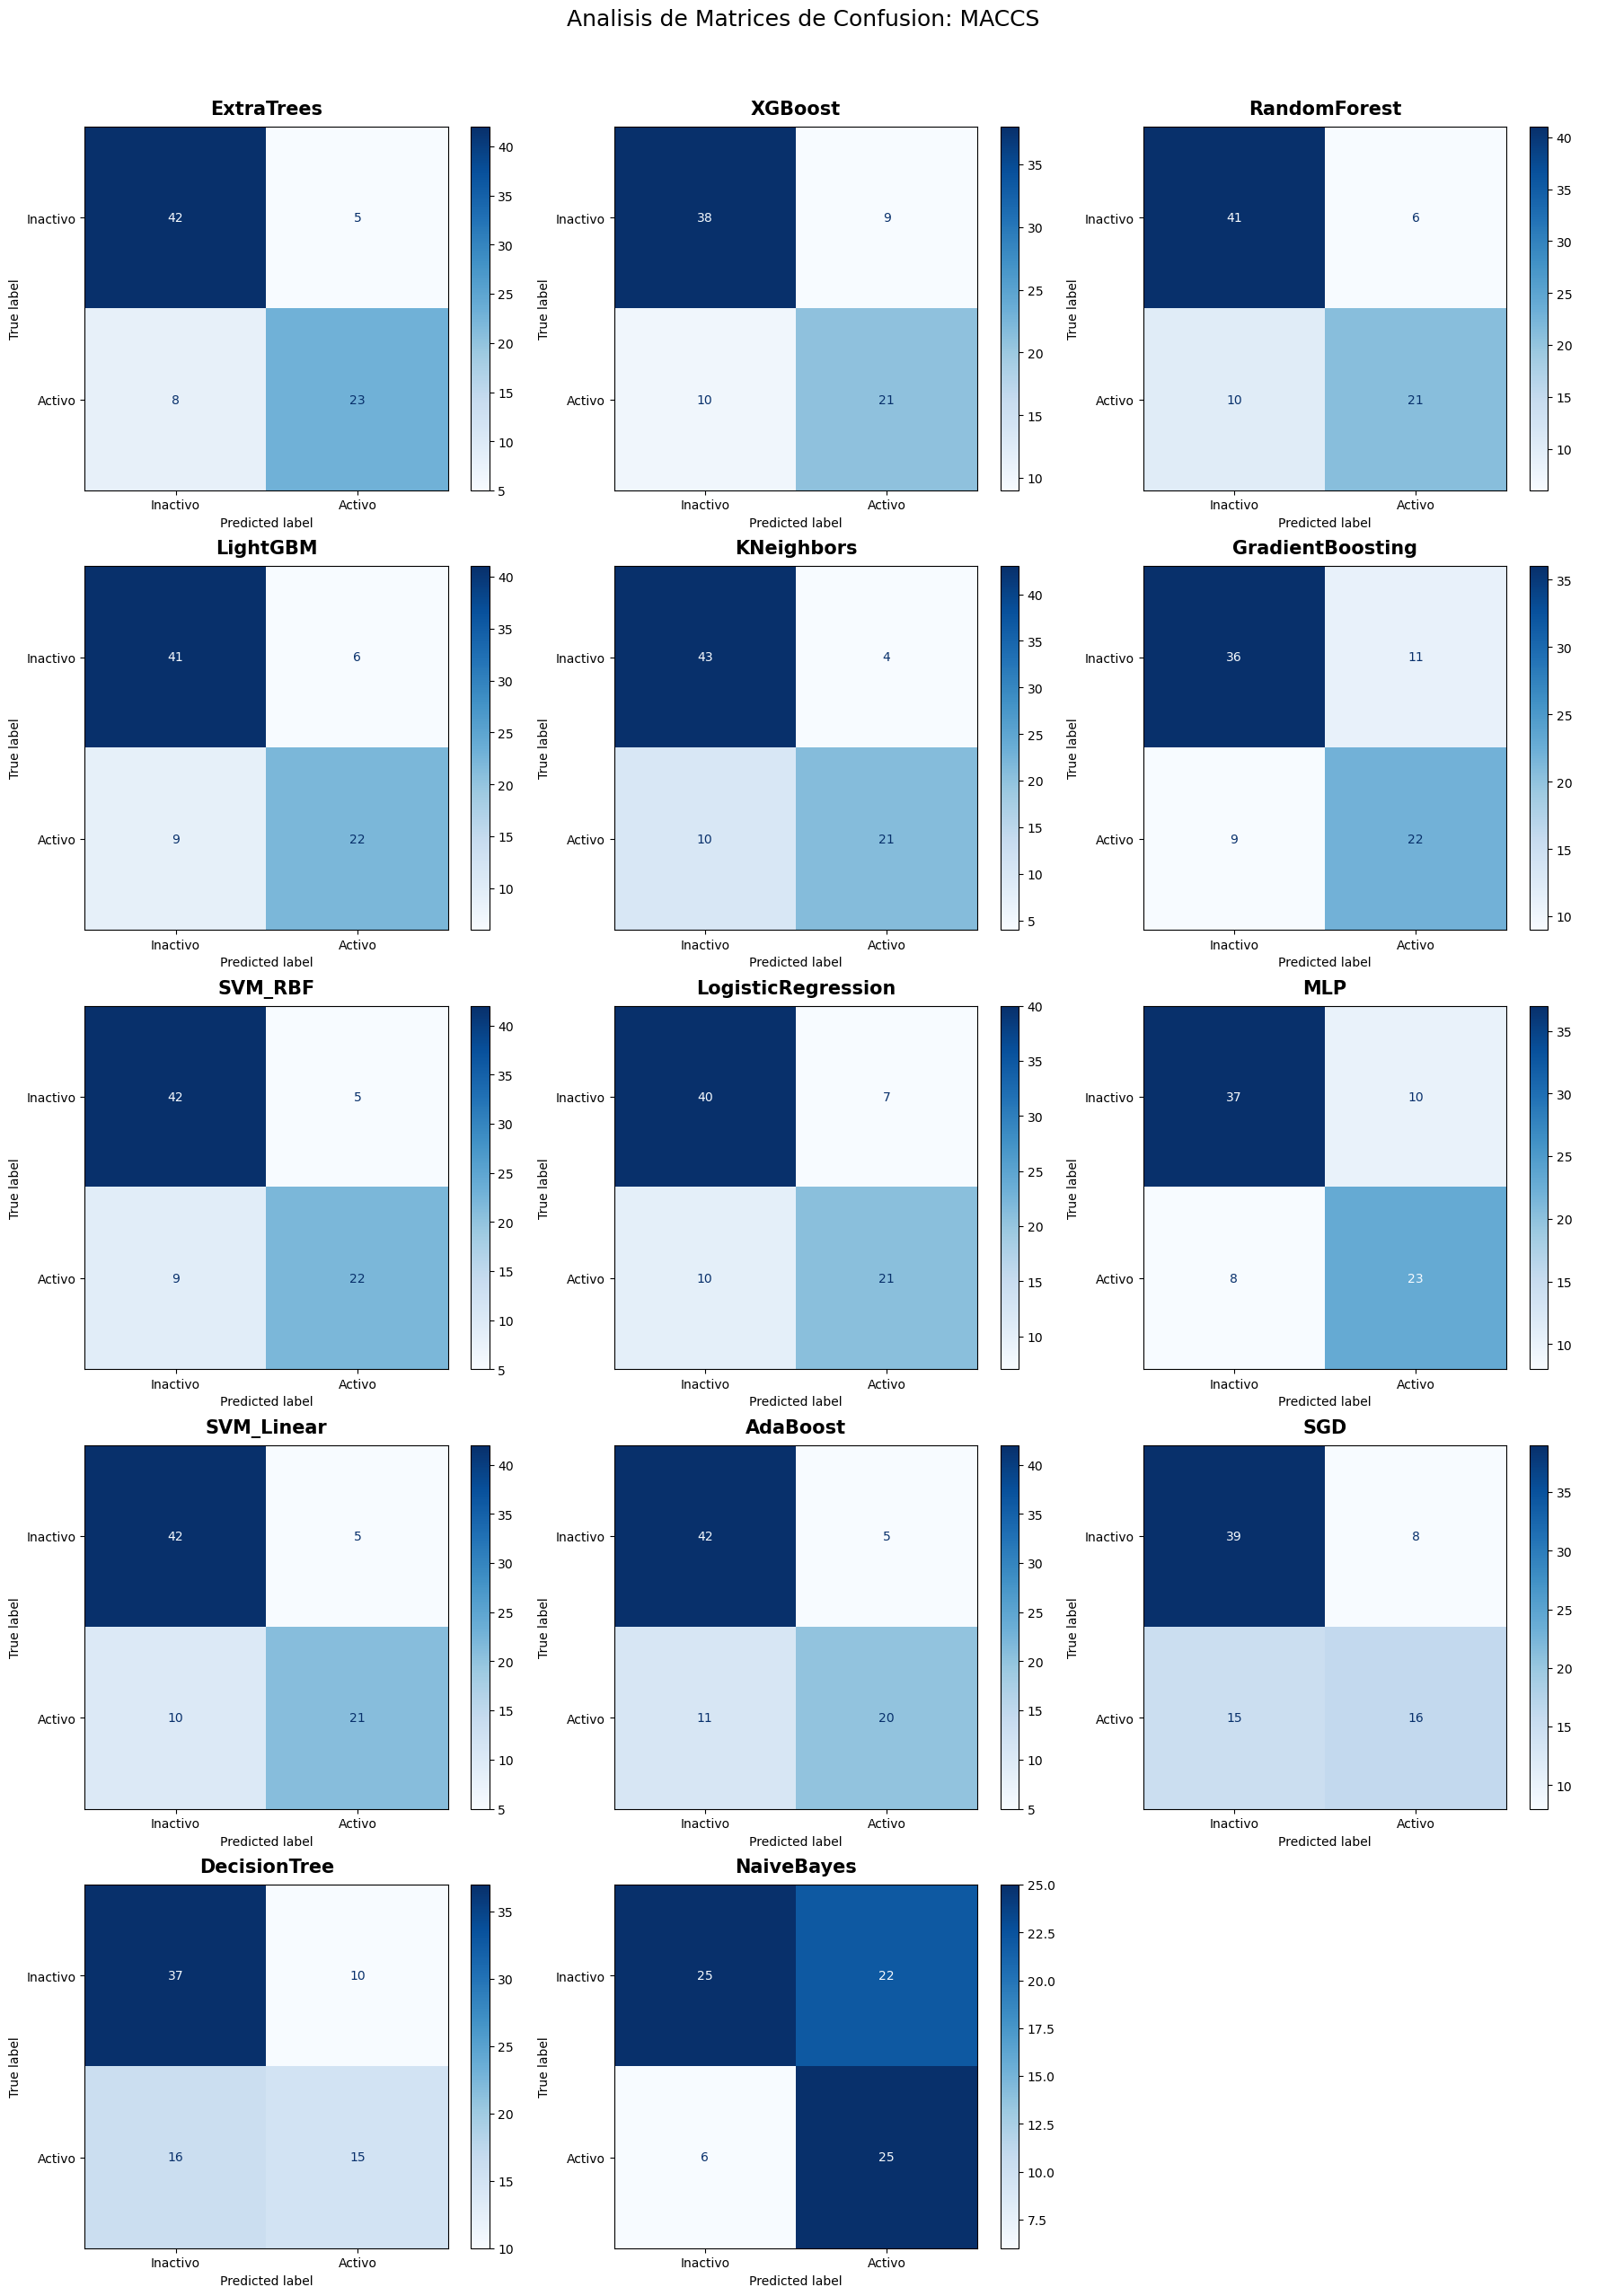

In [29]:
def plot_matrices_final(method_name, results_df, estimators_dict, feature_sets_dict):
    method_results = results_df[results_df["feature_set"].str.contains(method_name, case=False)]
    n_models = len(method_results)
    if n_models == 0: return
    cols = 3
    rows = math.ceil(n_models / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = axes.flatten()
    for i, (_, row) in enumerate(method_results.iterrows()):
        model_name = row['model']
        fs_name = row['feature_set']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols = feature_sets_dict[fs_name]
        y_pred = est.predict(X_test_full[fs_cols])
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Inactivo", "Activo"])
        disp.plot(ax=axes[i], colorbar=True, cmap="Blues")
        axes[i].set_title(f"{model_name}", fontsize=15, pad=10, fontweight='bold')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"Analisis de Matrices de Confusion: {method_name.upper()}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURAS}/paso7_confusion_{method_name}_final_maccs.png', dpi=150, bbox_inches="tight")
    plt.show()

plot_matrices_final("maccs", df_results, best_estimators, feature_sets)


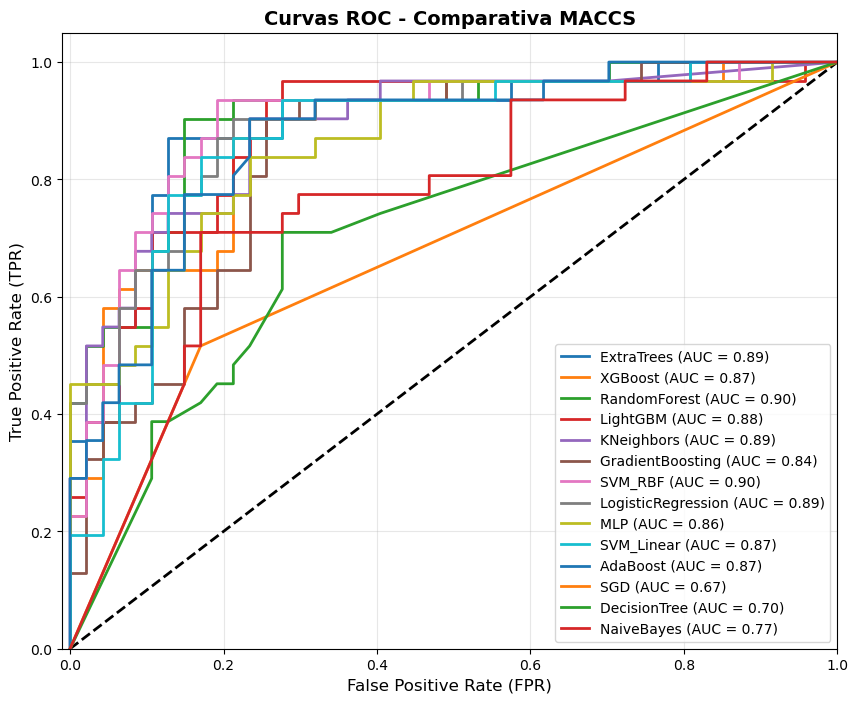

In [30]:
def plot_roc_curves_by_method(method_name, results_df, estimators_dict, feature_sets_dict):
    method_results = results_df[results_df["feature_set"].str.contains(method_name, case=False)]
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    for _, row in method_results.iterrows():
        model_name = row['model']
        fs_name = row['feature_set']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols = feature_sets_dict[fs_name]
        if hasattr(est, "predict_proba"):
            y_score = est.predict_proba(X_test_full[fs_cols])[:, 1]
        else:
            y_score = est.decision_function(X_test_full[fs_cols])
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title(f'Curvas ROC - Comparativa {method_name.upper()}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.savefig(f'{FIGURAS}/paso7_roc_comparison_{method_name}_maccs.png', dpi=150, bbox_inches="tight")
    plt.show()

plot_roc_curves_by_method("Maccs", df_results, best_estimators, feature_sets)


In [31]:
best_est = best_estimators[best_key]
best_fs  = feature_sets[best_row["feature_set"]]
y_pred   = best_est.predict(X_test_full[best_fs])

print(f"\n{'='*60}")
print(f"MEJOR MODELO (seleccionado por CV): {best_row['model']}")
print(f"Feature set  : {best_row['feature_set']} ({int(best_row['n_features'])} descriptores)")
print(f"CV ROC-AUC   : {best_row['cv_roc_auc_mean']:.4f} +/- {best_row['cv_roc_auc_std']:.4f}")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, target_names=["Inactivo", "Activo"]))
print(f"MCC = {matthews_corrcoef(y_test, y_pred):.4f}")
try:
    y_prob = best_est.predict_proba(X_test_full[best_fs])[:, 1]
    print(f"ROC-AUC (test) = {roc_auc_score(y_test, y_prob):.4f}")
except AttributeError:
    pass

pd.DataFrame(
    classification_report(y_test, y_pred,
                           target_names=["Inactivo", "Activo"],
                           output_dict=True)
).T.to_csv(f'{OUTPUT_DIR_ML}/paso7_report_mejor_modelo_maccs.csv')

print(f"\nGraficos y reportes del paso 7 guardados.")



MEJOR MODELO (seleccionado por CV): ExtraTrees
Feature set  : maccs_full (167 descriptores)
CV ROC-AUC   : 0.8667 +/- 0.0236
              precision    recall  f1-score   support

    Inactivo       0.84      0.89      0.87        47
      Activo       0.82      0.74      0.78        31

    accuracy                           0.83        78
   macro avg       0.83      0.82      0.82        78
weighted avg       0.83      0.83      0.83        78

MCC = 0.6484
ROC-AUC (test) = 0.8950

Graficos y reportes del paso 7 guardados.


In [32]:
# =============================================================================
# 5. Estimación robusta de rendimiento (Repeated Stratified-Group K-Fold)
# =============================================================================
# Con ~380 compuestos de train, un único split 80/20 es muy sensible a qué
# compuestos caen en cada lado. Repetimos la validación muchas veces para
# obtener una media +/- desviación estándar en vez de un solo número.

from sklearn.model_selection import StratifiedGroupKFold as _SGKF

n_repeats = 10
aucs, mccs = [], []

for rep in range(n_repeats):
    cv_rep = _SGKF(n_splits=5, shuffle=True, random_state=rep)
    for tr_i, te_i in cv_rep.split(X_full, y, groups=groups_all):
        pipe_rep = clone(best_est)
        pipe_rep.fit(X_full.iloc[tr_i], y.iloc[tr_i])
        prob = pipe_rep.predict_proba(X_full.iloc[te_i])[:, 1]
        pred = pipe_rep.predict(X_full.iloc[te_i])
        if len(np.unique(y.iloc[te_i])) > 1:
            aucs.append(roc_auc_score(y.iloc[te_i], prob))
        mccs.append(matthews_corrcoef(y.iloc[te_i], pred))

print(f"ROC-AUC  (repeated group-CV, {n_repeats}x5-fold): "
      f"{np.mean(aucs):.3f} +/- {np.std(aucs):.3f}")
print(f"MCC      (repeated group-CV, {n_repeats}x5-fold): "
      f"{np.mean(mccs):.3f} +/- {np.std(mccs):.3f}")



ROC-AUC  (repeated group-CV, 10x5-fold): 0.867 +/- 0.050
MCC      (repeated group-CV, 10x5-fold): 0.589 +/- 0.086


AUC real del modelo (test)     : 0.895
AUC con y-scrambling (20 veces) : 0.492 +/- 0.066
Si el AUC scrambled se acerca a 0.5, el modelo real está aprendiendo señal genuina y no ruido/artefactos.


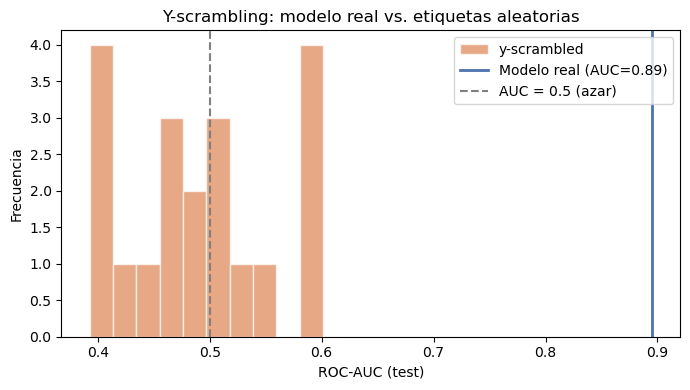

In [33]:
# =============================================================================
# 6. Control de y-scrambling
# =============================================================================
# Si el modelo obtiene buen AUC incluso con las etiquetas barajadas
# aleatoriamente, es señal de que está aprendiendo estructura espuria del
# dataset (p.ej. artefactos del split o de las features) y no una relación
# estructura-actividad real. Con etiquetas al azar el AUC esperado es ~0.5.

n_scrambles = 20
scrambled_aucs = []

rng = np.random.RandomState(RANDOM_STATE)
for i in range(n_scrambles):
    y_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index)
    m = clone(best_est)
    m.fit(X_train_full[best_fs], y_shuffled)
    p = m.predict_proba(X_test_full[best_fs])[:, 1]
    scrambled_aucs.append(roc_auc_score(y_test, p))

print(f"AUC real del modelo (test)     : {roc_auc_score(y_test, y_prob):.3f}")
print(f"AUC con y-scrambling ({n_scrambles} veces) : "
      f"{np.mean(scrambled_aucs):.3f} +/- {np.std(scrambled_aucs):.3f}")
print("Si el AUC scrambled se acerca a 0.5, el modelo real está aprendiendo "
      "señal genuina y no ruido/artefactos.")

plt.figure(figsize=(7, 4))
plt.hist(scrambled_aucs, bins=10, color='#DD8452', alpha=0.7, edgecolor='white',
         label='y-scrambled')
plt.axvline(roc_auc_score(y_test, y_prob), color='#4C72B0', linewidth=2,
            label=f"Modelo real (AUC={roc_auc_score(y_test, y_prob):.2f})")
plt.axvline(0.5, color='gray', linestyle='--', label='AUC = 0.5 (azar)')
plt.xlabel('ROC-AUC (test)')
plt.ylabel('Frecuencia')
plt.title('Y-scrambling: modelo real vs. etiquetas aleatorias')
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIGURAS}/paso7b_yscrambling_{best_row["model"]}_maccs.png', dpi=150, bbox_inches='tight')
plt.show()


TOP 3 MODELOS SELECCIONADOS PARA EL DOMINIO DE APLICABILIDAD (por CV)
       model feature_set  n_features  cv_roc_auc_mean  roc_auc_test
  ExtraTrees  maccs_full         167         0.866675      0.894990
     XGBoost  maccs_full         167         0.866160      0.872340
RandomForest  maccs_full         167         0.862530      0.903226

Descriptores (k)         : 167
Compuestos train (n)     : 311
Skewness de S_i (train)  : 2.9066  ->  multiplicador = 3.0
Umbral SDC               : 10.5687

Train - dentro del AD    : 308 (99.0%)
Train - fuera del AD     : 3 (1.0%)

Test  - dentro del AD    : 78 (100.0%)
Test  - fuera del AD     : 0 (0.0%)


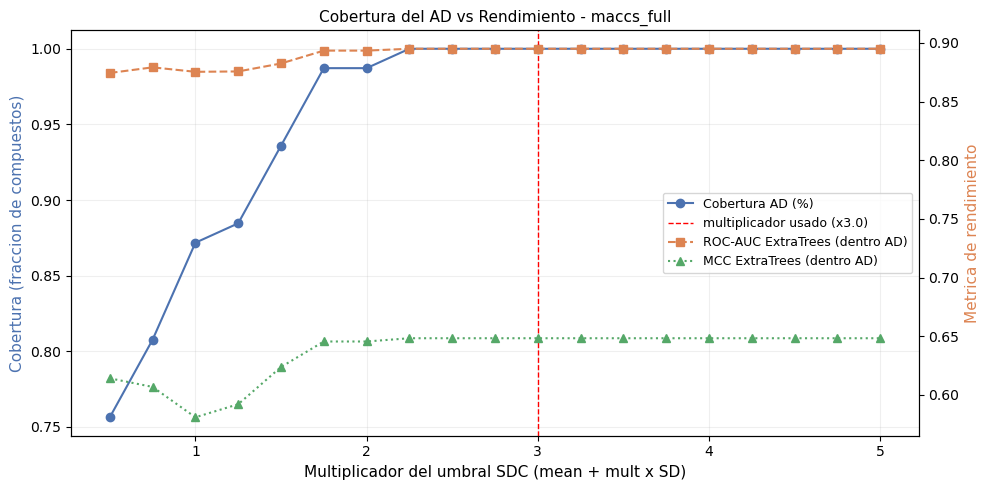

resultados dominio de aplicabilidad maccs/paso8_ad_coverage_maccs_full_maccs.png guardado.
split  in_AD
test   1         78
train  0          3
       1        308
resultados dominio de aplicabilidad maccs/paso8_standardization_maccs_full_maccs.csv guardado.

[1/3] MODELO: ExtraTrees  |  Feature set: maccs_full


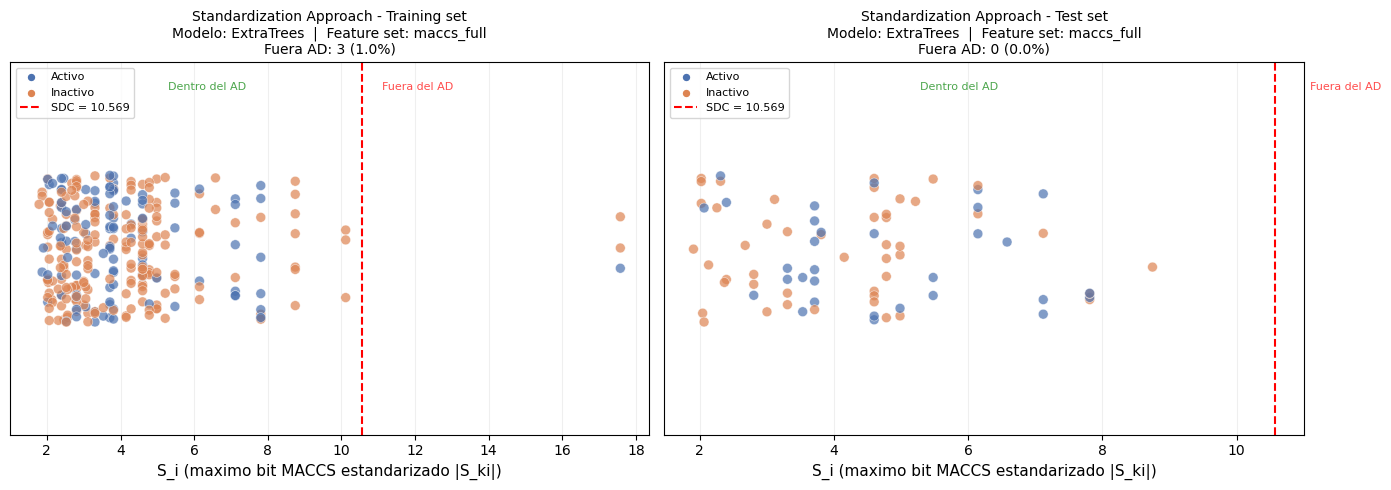

resultados dominio de aplicabilidad maccs/paso8_standardization_plot_top1_ExtraTrees_maccs.png guardado.

-- Test completo (n=78) --
  Accuracy  : 0.8333
  F1        : 0.7797
  MCC       : 0.6484
  ROC-AUC   : 0.8950

-- Test dentro del AD (n=78) --
  Accuracy  : 0.8333
  F1        : 0.7797
  MCC       : 0.6484
  ROC-AUC   : 0.8950

-- Test fuera del AD (n=0) --
  Accuracy  : nan
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad maccs/paso8_ad_metrics_top1_ExtraTrees_maccs.csv guardado.

[2/3] MODELO: XGBoost  |  Feature set: maccs_full


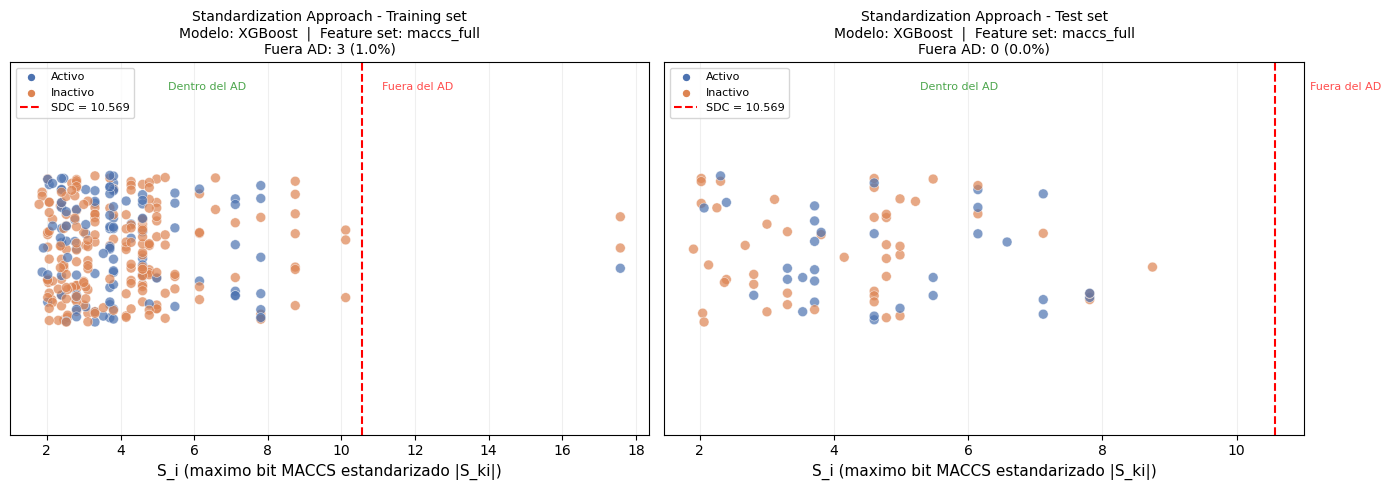

resultados dominio de aplicabilidad maccs/paso8_standardization_plot_top2_XGBoost_maccs.png guardado.

-- Test completo (n=78) --
  Accuracy  : 0.7564
  F1        : 0.6885
  MCC       : 0.4888
  ROC-AUC   : 0.8723

-- Test dentro del AD (n=78) --
  Accuracy  : 0.7564
  F1        : 0.6885
  MCC       : 0.4888
  ROC-AUC   : 0.8723

-- Test fuera del AD (n=0) --
  Accuracy  : nan
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad maccs/paso8_ad_metrics_top2_XGBoost_maccs.csv guardado.

[3/3] MODELO: RandomForest  |  Feature set: maccs_full


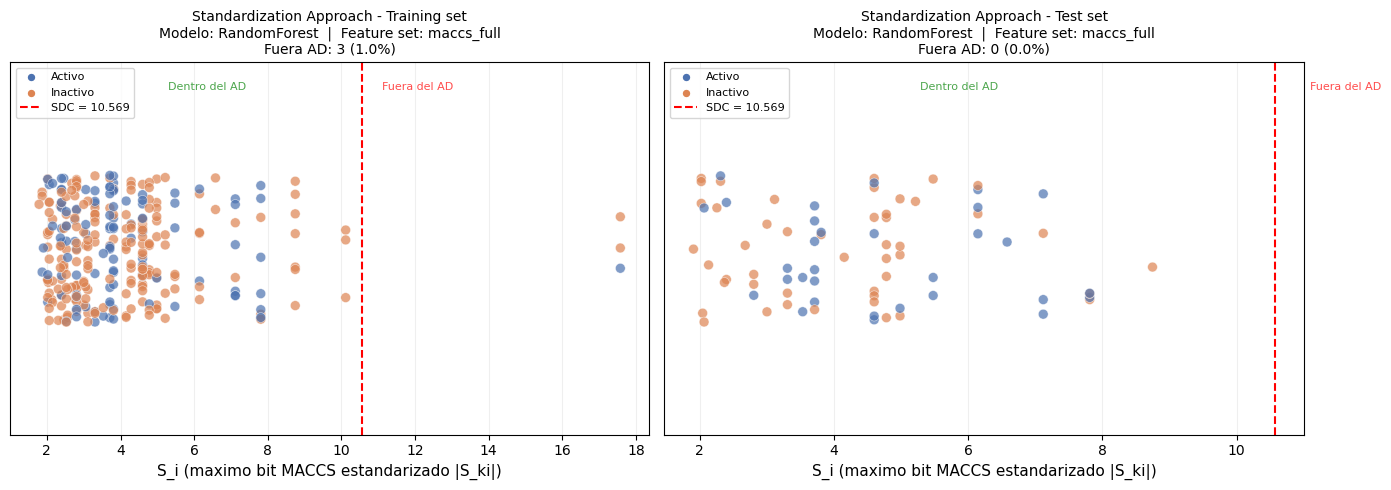

resultados dominio de aplicabilidad maccs/paso8_standardization_plot_top3_RandomForest_maccs.png guardado.

-- Test completo (n=78) --
  Accuracy  : 0.7949
  F1        : 0.7241
  MCC       : 0.5655
  ROC-AUC   : 0.9032

-- Test dentro del AD (n=78) --
  Accuracy  : 0.7949
  F1        : 0.7241
  MCC       : 0.5655
  ROC-AUC   : 0.9032

-- Test fuera del AD (n=0) --
  Accuracy  : nan
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad maccs/paso8_ad_metrics_top3_RandomForest_maccs.csv guardado.

RESUMEN COMPARATIVO - TOP 3 MODELOS (mismo AD, distinto clasificador)
 rank        model feature_set  roc_auc_all  roc_auc_in_AD  mcc_all  mcc_in_AD
    1   ExtraTrees  maccs_full       0.8950         0.8950   0.6484     0.6484
    2      XGBoost  maccs_full       0.8723         0.8723   0.4888     0.4888
    3 RandomForest  maccs_full       0.9032         0.9032   0.5655     0.5655

paraso8_summary_top3_maccs.csv guardado.


In [34]:
# =============================================================================
# 7. Dominio de aplicabilidad - Standardization Approach (TOP 3 modelos)
# =============================================================================
# Referencia: Roy, K., Kar, S., & Ambure, P. (2015). On a simple approach for
# determining applicability domain of QSAR models. Chemometrics and
# Intelligent Laboratory Systems, 145, 22-29.
#
# A diferencia del leverage/Williams plot (que se basa en la hat matrix de
# una regresion lineal, H = X(X'X)^-1 X'), este metodo trabaja unicamente
# sobre la distribucion estadistica de los descriptores (aqui, bits MACCS)
# estandarizados y no asume ninguna estructura de modelo. Es por tanto
# aplicable de la misma forma a modelos lineales y no lineales (RandomForest,
# XGBoost, SVM-RBF, MLP, etc.) - es agnostico al algoritmo de ML utilizado.
#
# El limite del AD (S_i, SDC) depende solo del feature set (aqui, unico:
# "maccs_full"), asi que se calcula UNA sola vez; pero se genera un GRAFICO
# INDIVIDUAL para cada uno de los 3 mejores modelos (misma frontera del AD,
# pero cada figura queda identificada con su propio modelo).
#
# Algoritmo:
#   1. Estandarizar cada bit MACCS con la media/SD del TRAIN set:
#        S_ki = (P_ki - mean_k) / SD_k
#   2. Para cada compuesto, quedarse con el maximo valor absoluto entre
#      todos sus bits estandarizados: S_i = max_k |S_ki|
#   3. Calcular la media y desviacion estandar de los S_i del train, y la
#      asimetria (skewness) de esa distribucion.
#   4. Definir el umbral de corte SDC = mean(S_i) + mult * SD(S_i), con
#      mult = 1.28 si la distribucion es aproximadamente simetrica
#      (|skewness| < 1) o mult = 3.0 si esta sesgada.
#   5. Compuestos (train o test) con S_i > SDC se consideran fuera del AD.

def metrics_summary(y_true, y_pred, y_prob, label):
    print(f"\n-- {label} (n={len(y_true)}) --")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"  MCC       : {matthews_corrcoef(y_true, y_pred):.4f}")
    if len(np.unique(y_true)) > 1:
        print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    return {
        'subset'  : label,
        'n'       : len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'f1'      : f1_score(y_true, y_pred),
        'mcc'     : matthews_corrcoef(y_true, y_pred),
        'roc_auc' : roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }

def standardization_approach_ad(X_train: pd.DataFrame, X_test: pd.DataFrame):
    mean_train = X_train.mean()
    std_train  = X_train.std().replace(0, 1)  # evita division por cero en bits casi constantes

    S_train = ((X_train - mean_train) / std_train).abs().max(axis=1)
    S_test  = ((X_test  - mean_train) / std_train).abs().max(axis=1)

    skewness = S_train.skew()
    mult = 1.28 if abs(skewness) < 1 else 3.0
    SDC  = S_train.mean() + mult * S_train.std()
    return S_train, S_test, SDC, skewness, mult


def plot_ad_for_model(model_name, S_train, S_test, SDC, fs_name, y_train, y_test, model_tag):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (S, y_lbl, split_name) in zip(
        axes,
        [
            (S_train, y_train, 'Training set'),
            (S_test,  y_test,  'Test set'),
        ]
    ):
        out_ad = S > SDC
        colors = np.where(y_lbl == 1, '#4C72B0', '#DD8452')
        jitter = np.random.RandomState(42).uniform(-0.4, 0.4, size=len(S))

        ax.scatter(S, jitter, c=colors, alpha=0.7, edgecolors='white',
                   linewidths=0.4, s=50, zorder=3)
        ax.axvline(SDC, color='red', linestyle='--', linewidth=1.5, label=f'SDC = {SDC:.3f}')
        ax.set_ylim(-1, 1)
        ax.set_yticks([])
        ax.text(SDC * 0.5, 0.85, 'Dentro del AD', fontsize=8, color='green', alpha=0.7)
        ax.text(SDC * 1.05, 0.85, 'Fuera del AD',  fontsize=8, color='red',   alpha=0.7)

        legend_patches = [
            plt.scatter([], [], c='#4C72B0', s=40, label='Activo',   edgecolors='white'),
            plt.scatter([], [], c='#DD8452', s=40, label='Inactivo', edgecolors='white'),
        ]
        ax.legend(handles=legend_patches + [
            plt.Line2D([0], [0], color='red', linestyle='--', label=f'SDC = {SDC:.3f}'),
        ], fontsize=8, loc='upper left')

        ax.set_xlabel('S_i (maximo bit MACCS estandarizado |S_ki|)', fontsize=11)
        ax.set_title(
            f'Standardization Approach - {split_name}\n'
            f'Modelo: {model_name}  |  Feature set: {fs_name}\n'
            f'Fuera AD: {out_ad.sum()} ({out_ad.mean():.1%})',
            fontsize=10
        )
        ax.grid(alpha=0.2, axis='x')

    plt.tight_layout()
    out_std = f'{OUTPUT_DIR_AD}/paso8_standardization_plot_{model_tag}_maccs.png'
    plt.savefig(out_std, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{out_std} guardado.')


top3 = df_results.head(3).reset_index(drop=True)

print("=" * 60)
print("TOP 3 MODELOS SELECCIONADOS PARA EL DOMINIO DE APLICABILIDAD (por CV)")
print("=" * 60)
cols_show = ["model", "feature_set", "n_features", "cv_roc_auc_mean", "roc_auc_test"]
print(top3[cols_show].to_string(index=False))
print()

fs_name = top3.iloc[0]["feature_set"]   # "maccs_full" (unico feature set en MACCS)
fs_cols = feature_sets[fs_name]
best_key = f"{top3.iloc[0]['model']}__{fs_name}"

# ── Standardization approach: se calcula UNA vez (unico feature set) ────────
S_train, S_test, SDC, skewness, mult = standardization_approach_ad(
    X_train_full[fs_cols], X_test_full[fs_cols]
)

print(f"Descriptores (k)         : {len(fs_cols)}")
print(f"Compuestos train (n)     : {len(X_train_full)}")
print(f"Skewness de S_i (train)  : {skewness:.4f}  ->  multiplicador = {mult}")
print(f"Umbral SDC               : {SDC:.4f}")
print()
print(f"Train - dentro del AD    : {(S_train <= SDC).sum()} ({(S_train <= SDC).mean():.1%})")
print(f"Train - fuera del AD     : {(S_train >  SDC).sum()} ({(S_train >  SDC).mean():.1%})")
print()
print(f"Test  - dentro del AD    : {(S_test  <= SDC).sum()} ({(S_test  <= SDC).mean():.1%})")
print(f"Test  - fuera del AD     : {(S_test  >  SDC).sum()} ({(S_test  >  SDC).mean():.1%})")

mask_ad = (S_test <= SDC).values

# ── Cobertura del AD vs rendimiento del top1, variando el umbral SDC ────────
multipliers = np.arange(0.5, 5.1, 0.25)
top1_est = best_estimators[best_key]
y_pred_top1 = top1_est.predict(X_test_full[fs_cols])
y_prob_top1 = (top1_est.predict_proba(X_test_full[fs_cols])[:, 1]
               if hasattr(top1_est, "predict_proba")
               else top1_est.decision_function(X_test_full[fs_cols]))

coverages, aucs_cov, mccs_cov = [], [], []
for m in multipliers:
    thr = S_train.mean() + m * S_train.std()
    mask = (S_test <= thr).values
    coverages.append(mask.mean())
    if mask.sum() > 5 and len(np.unique(y_test[mask])) > 1:
        aucs_cov.append(roc_auc_score(y_test[mask], y_prob_top1[mask]))
        mccs_cov.append(matthews_corrcoef(y_test[mask], y_pred_top1[mask]))
    else:
        aucs_cov.append(np.nan)
        mccs_cov.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(multipliers, coverages, 'o-',  color='#4C72B0', label='Cobertura AD (%)')
ax2.plot(multipliers, aucs_cov,  's--', color='#DD8452', label=f'ROC-AUC {top3.iloc[0]["model"]} (dentro AD)')
ax2.plot(multipliers, mccs_cov,  '^:',  color='#55A868', label=f'MCC {top3.iloc[0]["model"]} (dentro AD)')
ax1.axvline(mult, color='red', linestyle='--', linewidth=1, label=f'multiplicador usado (x{mult})')
ax1.set_xlabel('Multiplicador del umbral SDC (mean + mult x SD)', fontsize=11)
ax1.set_ylabel('Cobertura (fraccion de compuestos)', fontsize=11, color='#4C72B0')
ax2.set_ylabel('Metrica de rendimiento', fontsize=11, color='#DD8452')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax1.set_title(f'Cobertura del AD vs Rendimiento - {fs_name}', fontsize=11)
ax1.grid(alpha=0.2)
plt.tight_layout()
out_cov = f'{OUTPUT_DIR_AD}/paso8_ad_coverage_{fs_name}_maccs.png'
plt.savefig(out_cov, dpi=150, bbox_inches='tight')
plt.show()
print(f'{out_cov} guardado.')

# ── Guardar S_i por compuesto (train + test), una vez por feature set ───────
df_ad_train = pd.DataFrame({
    'smiles_std' : df_final.loc[train_orig_idx, 'smiles_std'].values,
    'split'      : 'train',
    'S_i'        : S_train.values,
    'label'      : y_train.values,
    'in_AD'      : (S_train <= SDC).astype(int).values,
    'feature_set': fs_name,
})
df_ad_test = pd.DataFrame({
    'smiles_std' : df_final.loc[test_orig_idx, 'smiles_std'].values,
    'split'      : 'test',
    'S_i'        : S_test.values,
    'label'      : y_test.values,
    'in_AD'      : (S_test <= SDC).astype(int).values,
    'feature_set': fs_name,
})
df_ad_all = pd.concat([df_ad_train, df_ad_test], ignore_index=True)
out_si = f'{OUTPUT_DIR_AD}/paso8_standardization_{fs_name}_maccs.csv'
df_ad_all.to_csv(out_si, index=False)
print(df_ad_all.groupby(['split', 'in_AD']).size().rename('n_compuestos').to_string())
print(f'{out_si} guardado.')

# =============================================================================
# Grafico + rendimiento dentro / fuera del AD, POR CADA UNO de los 3 modelos
# =============================================================================
summary_rows = []
for rank, row in top3.iterrows():
    rank += 1
    model_name = row["model"]
    key        = f"{model_name}__{fs_name}"
    est        = best_estimators[key]
    model_tag  = f"top{rank}_{model_name}"

    print("\n" + "=" * 60)
    print(f"[{rank}/3] MODELO: {model_name}  |  Feature set: {fs_name}")
    print("=" * 60)

    # Grafico del AD individual para este modelo (misma frontera S_i/SDC,
    # pero figura propia identificada con el nombre del modelo)
    plot_ad_for_model(model_name, S_train, S_test, SDC, fs_name, y_train, y_test, model_tag)

    y_pred_test = est.predict(X_test_full[fs_cols])
    y_prob_test = (est.predict_proba(X_test_full[fs_cols])[:, 1]
                   if hasattr(est, "predict_proba")
                   else est.decision_function(X_test_full[fs_cols]))

    r_all = metrics_summary(y_test, y_pred_test, y_prob_test, 'Test completo')
    r_ad  = metrics_summary(y_test[mask_ad], y_pred_test[mask_ad], y_prob_test[mask_ad], 'Test dentro del AD')
    r_out = metrics_summary(y_test[~mask_ad], y_pred_test[~mask_ad], y_prob_test[~mask_ad], 'Test fuera del AD')

    df_ad_metrics = pd.DataFrame([r_all, r_ad, r_out])
    df_ad_metrics['model']       = model_name
    df_ad_metrics['feature_set'] = fs_name
    out_metrics = f'{OUTPUT_DIR_AD}/paso8_ad_metrics_{model_tag}_maccs.csv'
    df_ad_metrics.to_csv(out_metrics, index=False)
    print(f"{out_metrics} guardado.")

    summary_rows.append({
        'rank'          : rank,
        'model'         : model_name,
        'feature_set'   : fs_name,
        'roc_auc_all'   : round(roc_auc_score(y_test, y_prob_test), 4),
        'roc_auc_in_AD' : round(r_ad['roc_auc'], 4) if not np.isnan(r_ad['roc_auc']) else np.nan,
        'mcc_all'       : round(r_all['mcc'], 4),
        'mcc_in_AD'     : round(r_ad['mcc'], 4),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(f'{OUTPUT_DIR_AD}/paso8_summary_top3_maccs.csv', index=False)
print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO - TOP 3 MODELOS (mismo AD, distinto clasificador)")
print("=" * 60)
print(df_summary.to_string(index=False))
print('\nparaso8_summary_top3_maccs.csv guardado.')



[1/3] Permutation importance: ExtraTrees | maccs_full (167 bits MACCS)
Top 20 bits MACCS por importancia (ROC-AUC):
descriptor  importance_mean  importance_std       effect
 MACCS_152         0.007344        0.004257 positivo (+)
 MACCS_151         0.006429        0.003778 positivo (+)
  MACCS_23         0.006269        0.002744 negativo (-)
 MACCS_135         0.005559        0.005110 negativo (-)
 MACCS_140         0.003683        0.005300 positivo (+)
  MACCS_93         0.003638        0.002769 positivo (+)
  MACCS_41         0.003523        0.003338 positivo (+)
  MACCS_37         0.003432        0.003090 positivo (+)
  MACCS_65         0.003249        0.001866 negativo (-)
  MACCS_86         0.003111        0.005247 positivo (+)
  MACCS_80         0.003066        0.005169 negativo (-)
 MACCS_109         0.003020        0.002638 positivo (+)
 MACCS_146         0.002928        0.002351 positivo (+)
 MACCS_102         0.002860        0.002029 positivo (+)
  MACCS_88         0.002608 

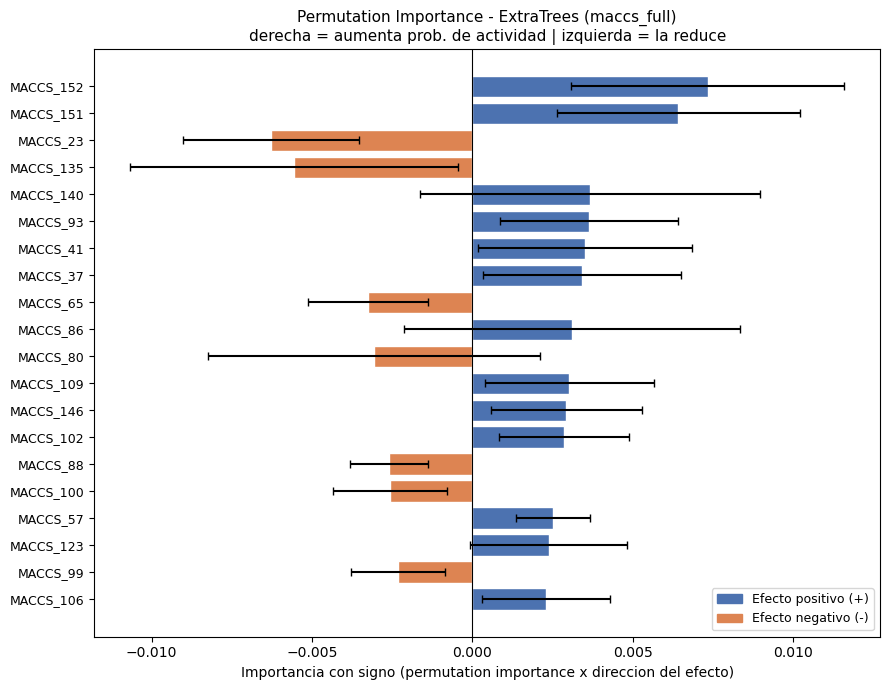

figuras/paso9_permutation_importance_top1_ExtraTrees_maccs.png guardado.

[2/3] Permutation importance: XGBoost | maccs_full (167 bits MACCS)
Top 20 bits MACCS por importancia (ROC-AUC):
descriptor  importance_mean  importance_std       effect
 MACCS_152         0.031206        0.021322 positivo (+)
  MACCS_91         0.022215        0.007389 negativo (-)
  MACCS_54         0.019103        0.010421 positivo (+)
 MACCS_151         0.016221        0.009883 positivo (+)
  MACCS_23         0.014390        0.007584 negativo (-)
 MACCS_115         0.010844        0.011276 positivo (+)
  MACCS_97         0.009288        0.005670 negativo (-)
 MACCS_112         0.007779        0.003676 positivo (+)
 MACCS_132         0.007435        0.007343 negativo (-)
 MACCS_153         0.007092        0.007507 positivo (+)
 MACCS_103         0.006726        0.005010 positivo (+)
  MACCS_43         0.006223        0.002675 positivo (+)
 MACCS_120         0.005399        0.003218 negativo (-)
  MACCS_64     

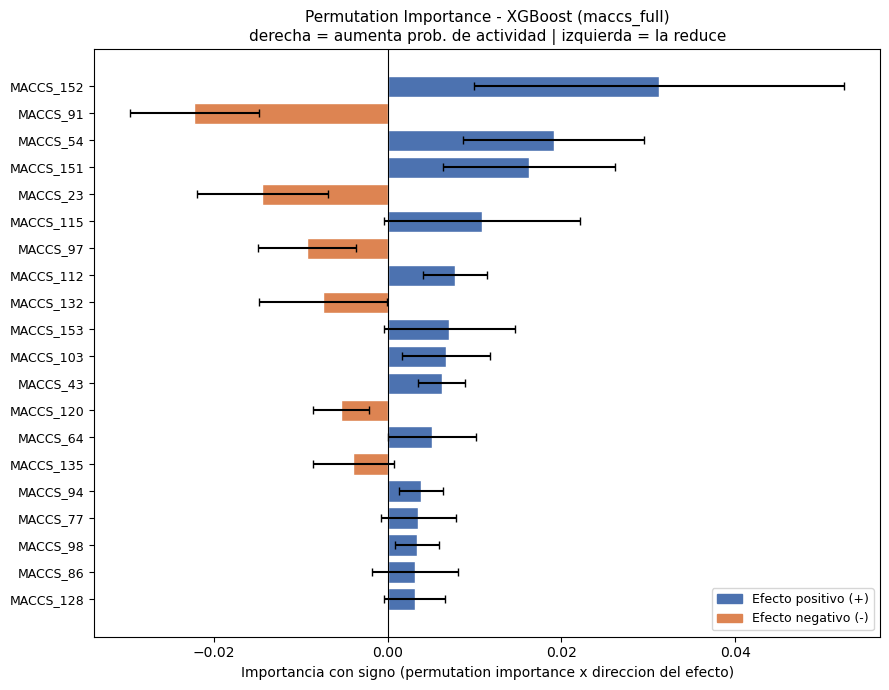

figuras/paso9_permutation_importance_top2_XGBoost_maccs.png guardado.

[3/3] Permutation importance: RandomForest | maccs_full (167 bits MACCS)
Top 20 bits MACCS por importancia (ROC-AUC):
descriptor  importance_mean  importance_std       effect
 MACCS_153         0.012080        0.006520 positivo (+)
 MACCS_152         0.011187        0.005646 positivo (+)
  MACCS_23         0.006886        0.001820 negativo (-)
  MACCS_37         0.006680        0.002384 positivo (+)
  MACCS_86         0.006063        0.003684 positivo (+)
 MACCS_134         0.005628        0.002643 negativo (-)
 MACCS_143         0.005399        0.002376 negativo (-)
  MACCS_91         0.005399        0.003037 negativo (-)
 MACCS_135         0.005148        0.004674 negativo (-)
 MACCS_146         0.005102        0.003366 positivo (+)
  MACCS_69         0.005033        0.002546 positivo (+)
  MACCS_77         0.004850        0.002255 positivo (+)
  MACCS_76         0.004804        0.001875 negativo (-)
  MACCS_94   

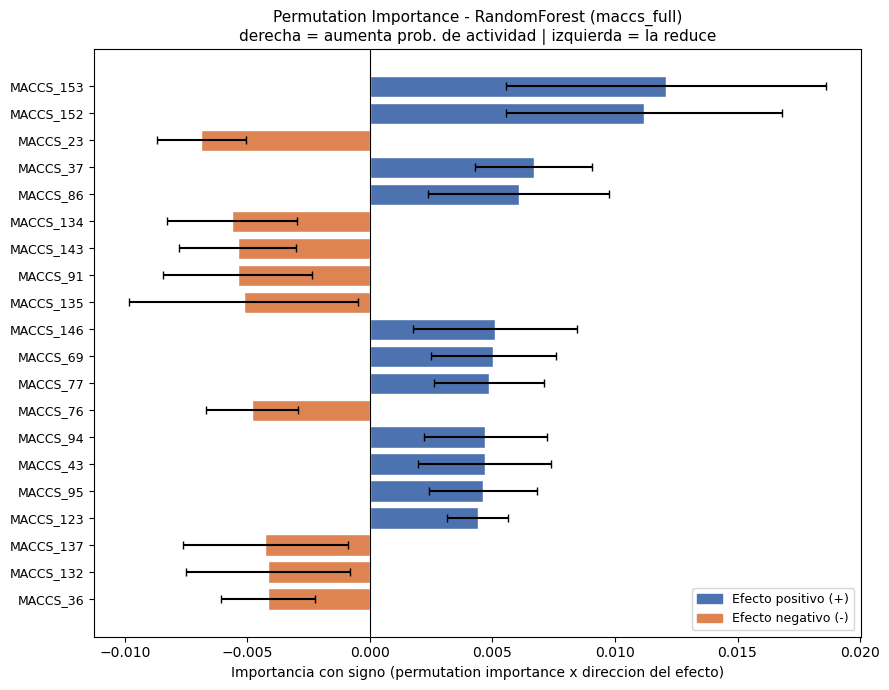

figuras/paso9_permutation_importance_top3_RandomForest_maccs.png guardado.

paraso9_permutation_importance_all.csv guardado con la importancia de los TOP 3 modelos.


In [35]:
# =============================================================================
# 8. Interpretabilidad: Permutation Feature Importance (TOP 3 modelos)
# =============================================================================
# La importancia por permutacion mide cuanto empeora el rendimiento del
# modelo (ROC-AUC) al barajar aleatoriamente los valores de un bit MACCS,
# rompiendo su relacion con la actividad. Se calcula sobre el TEST SET (no
# sobre train), para que refleje la contribucion real del bit a la capacidad
# de generalizacion, no a su ajuste a los datos de entrenamiento.
#
# La importancia por permutacion solo mide MAGNITUD (cuanto importa), no
# DIRECCION (si el bit favorece o penaliza la actividad). Para estimar la
# direccion se calcula la correlacion de Pearson entre el valor del bit (0/1)
# y la probabilidad predicha por el propio modelo en el test set: correlacion
# positiva -> la presencia de ese fragmento estructural aumenta la
# probabilidad de actividad; negativa -> la reduce. Es una aproximacion (no
# capta relaciones no monotonas), pero es el criterio habitual en QSAR cuando
# se usan modelos no lineales que no tienen coeficientes directos.
#
# En el grafico, la barra se dibuja hacia la DERECHA si el bit MACCS tiene
# efecto positivo sobre la actividad y hacia la IZQUIERDA si tiene efecto
# negativo (importancia con signo = importancia * signo de la correlacion).
#
# Se reutilizan los mismos TOP 3 modelos (top3) y el mismo feature set
# (fs_name / fs_cols) ya seleccionados en la seccion de Dominio de Aplicabilidad.

N_TOP_DESCRIPTORS = 20
N_REPEATS_PI       = 30

def permutation_importance_report(model_name, est, fs_name, feat_cols, X_te, y_te,
                                   n_repeats=N_REPEATS_PI, random_state=42):
    result = permutation_importance(
        est, X_te[feat_cols], y_te,
        scoring="roc_auc",
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1,
    )

    if hasattr(est, "predict_proba"):
        y_prob = est.predict_proba(X_te[feat_cols])[:, 1]
    else:
        y_prob = est.decision_function(X_te[feat_cols])

    directions = []
    for col in feat_cols:
        col_vals = X_te[col].values
        if np.std(col_vals) == 0:
            directions.append(0.0)
        else:
            r, _ = pearsonr(col_vals, y_prob)
            directions.append(r)

    imp_df = pd.DataFrame({
        "descriptor"     : feat_cols,
        "importance_mean": result.importances_mean,
        "importance_std" : result.importances_std,
        "direction_corr" : directions,
    })
    imp_df["sign"] = np.where(imp_df["direction_corr"] >= 0, 1, -1)
    imp_df["signed_importance"] = imp_df["importance_mean"] * imp_df["sign"]
    imp_df["effect"] = np.where(imp_df["direction_corr"] >= 0, "positivo (+)", "negativo (-)")
    imp_df = imp_df.reindex(
        imp_df["importance_mean"].sort_values(ascending=False).index
    ).reset_index(drop=True)
    imp_df.insert(0, "model", model_name)
    imp_df.insert(1, "feature_set", fs_name)
    return imp_df


all_importance_dfs = []

for rank, row in top3.iterrows():
    rank += 1
    model_name = row["model"]
    key        = f"{model_name}__{fs_name}"
    est        = best_estimators[key]

    print("\n" + "=" * 60)
    print(f"[{rank}/3] Permutation importance: {model_name} | {fs_name} ({len(fs_cols)} bits MACCS)")
    print("=" * 60)

    imp_df = permutation_importance_report(model_name, est, fs_name, fs_cols, X_test_full, y_test)
    all_importance_dfs.append(imp_df)

    top_n = imp_df.head(N_TOP_DESCRIPTORS)
    out_csv = f'{OUTPUT_DIR_INT}/paso9_permutation_importance_top{rank}_{model_name}.csv'
    imp_df.to_csv(out_csv, index=False)
    print(f"Top {N_TOP_DESCRIPTORS} bits MACCS por importancia (ROC-AUC):")
    print(top_n[["descriptor", "importance_mean", "importance_std", "effect"]].to_string(index=False))
    print(f"{out_csv} guardado.")

    # Orden visual: de mayor a menor importancia absoluta, de arriba a abajo
    top_n_plot = top_n.iloc[::-1]
    colors = np.where(top_n_plot["sign"] > 0, "#4C72B0", "#DD8452")

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(top_n_plot))))
    y_pos = np.arange(len(top_n_plot))
    ax.barh(y_pos, top_n_plot["signed_importance"],
            xerr=top_n_plot["importance_std"],
            color=colors, edgecolor="white", capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_n_plot["descriptor"], fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Importancia con signo (permutation importance x direccion del efecto)")
    ax.set_title(f"Permutation Importance - {model_name} ({fs_name})\n"
                 f"derecha = aumenta prob. de actividad | izquierda = la reduce", fontsize=11)
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, color="#4C72B0", label="Efecto positivo (+)"),
        plt.Rectangle((0, 0), 1, 1, color="#DD8452", label="Efecto negativo (-)"),
    ]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
    plt.tight_layout()
    out_png = f'{FIGURAS}/paso9_permutation_importance_top{rank}_{model_name}_maccs.png'
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{out_png} guardado.")

df_importance_all = pd.concat(all_importance_dfs, ignore_index=True)
df_importance_all.to_csv(f'{OUTPUT_DIR_INT}/paso9_permutation_importance_all.csv', index=False)
print(f"\nparaso9_permutation_importance_all.csv guardado con la importancia de los TOP 3 modelos.")
